In [1]:
!pip install transformers datasets evaluate scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [2]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [3]:
import os

print(os.listdir("/kaggle/input/datasets/susandilinn/dataset"))

['AI3.json', 'AI6.json', 'AI7.json', 'AI5.json', 'AI1.json', '5_robotics_labeled_dataset.json', '1_robotics_labeled_dataset.json', 'AI2.json', 'AI4s.json', '3_robotics_labeled_dataset.json', '2_robotics_labeled_dataset.json']


In [4]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="/kaggle/input/datasets/susandilinn/dataset/*.json"
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input', 'label'],
        num_rows: 792
    })
})

In [5]:
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['input', 'label'],
    num_rows: 633
})
Dataset({
    features: ['input', 'label'],
    num_rows: 159
})


In [6]:
print(train_dataset.column_names)

['input', 'label']


In [7]:
import pandas as pd

# Convert to pandas for easy inspection
df = pd.DataFrame(train_dataset)

print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

label
0    397
1    236
Name: count, dtype: int64

Percentage:
label
0    62.71722
1    37.28278
Name: proportion, dtype: float64


In [8]:
train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

In [9]:
def convert_labels(example):
    example["labels"] = int(example["labels"])
    return example

train_dataset = train_dataset.map(convert_labels)
test_dataset = test_dataset.map(convert_labels)

Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Map:   0%|          | 0/159 [00:00<?, ? examples/s]

In [10]:
model_name = "bert-base-uncased"
# model_name = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
def tokenize_function(example):
    return tokenizer(
        example["input"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/633 [00:00<?, ? examples/s]

Map:   0%|          | 0/159 [00:00<?, ? examples/s]

In [12]:
train_dataset = train_dataset.remove_columns(["input"])
test_dataset = test_dataset.remove_columns(["input"])

In [13]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "token_type_ids", "labels"]
)

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "roc_auc": auc
    }

In [15]:
# training_args = TrainingArguments(
#     output_dir="./results",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     logging_dir="./logs",
#     load_best_model_at_end=True
# )

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1.5e-5,        # smaller LR = more stable
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.05,           # stronger regularization
    warmup_ratio=0.1,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    greater_is_better=True,
    save_total_limit=2
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Roc Auc
1,No log,0.843228,0.842767,0.910549
2,No log,0.722314,0.842767,0.921462
3,No log,0.651959,0.867925,0.925099
4,No log,0.654093,0.874214,0.922454
5,No log,0.642083,0.874214,0.926422


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=200, training_loss=0.6620139312744141, metrics={'train_runtime': 66.6247, 'train_samples_per_second': 47.505, 'train_steps_per_second': 3.002, 'total_flos': 208186622553600.0, 'train_loss': 0.6620139312744141, 'epoch': 5.0})

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


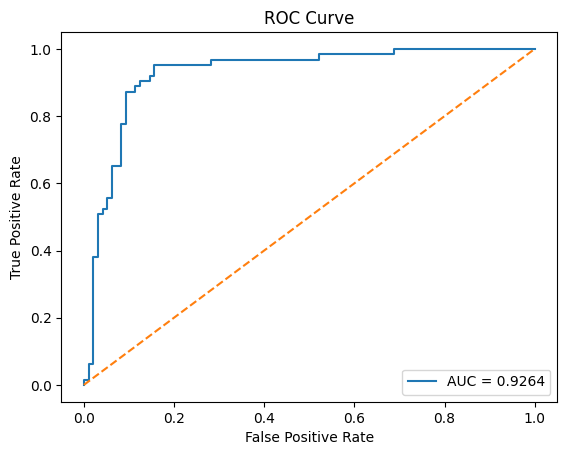

In [17]:
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
labels = predictions.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

fpr, tpr, thresholds = roc_curve(labels, probs)
auc_score = roc_auc_score(labels, probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [18]:
custom_threshold = 0.7

custom_preds = (probs >= custom_threshold).astype(int)

accuracy = accuracy_score(labels, custom_preds)

print("Custom Threshold:", custom_threshold)
print("Accuracy:", accuracy)

Custom Threshold: 0.7
Accuracy: 0.8805031446540881


In [19]:
trainer.save_model("./my_bert_model")
tokenizer.save_pretrained("./my_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./my_bert_model/tokenizer_config.json', './my_bert_model/tokenizer.json')

## testing with pdf files

In [20]:
import os
print(os.listdir("/kaggle/working/my_bert_model"))

['config.json', 'training_args.bin', 'tokenizer.json', 'model.safetensors', 'tokenizer_config.json']


In [21]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "/kaggle/working/my_bert_model"  # your saved model

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [22]:
!pip install pdfplumber scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 98.2 MB/s eta 0:00:00


In [23]:
import re
import pdfplumber
from pathlib import Path

def extract_text_from_pdf(pdf_path):
    all_text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                all_text += page_text + "\n"

    # Remove URLs
    all_text = re.sub(r"http\S+", "", all_text)
    all_text = re.sub(r"www\.\S+", "", all_text)

    return all_text

In [24]:
def remove_consecutive_duplicates(text):
    lines = text.split("\n")
    cleaned = []
    prev_line = None

    for line in lines:
        stripped = line.strip()
        if stripped == prev_line:
            continue
        cleaned.append(line)
        prev_line = stripped

    return "\n".join(cleaned)


def remove_equation_lines(text):
    cleaned_lines = []

    for line in text.split("\n"):
        stripped = line.strip()

        if not stripped:
            cleaned_lines.append("")
            continue

        math_symbol_ratio = sum(c in "𝜃𝑥𝑦𝑋𝑌𝒚𝜽=∗+-^()⋯" for c in stripped) / len(stripped)

        if math_symbol_ratio > 0.3:
            continue

        if re.fullmatch(r"[0-9\s=+\-*/().]+", stripped):
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def clean_text_structured(text: str) -> str:
    text = text.replace('\ufeff', '')
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'[•◦▪–—]', '-', text)

    lines = [l.strip() for l in text.split('\n')]

    cleaned = []
    buffer = ""

    for line in lines:
        if not line:
            if buffer:
                cleaned.append(buffer)
                buffer = ""
            cleaned.append("")
            continue

        if line.startswith("-"):
            if buffer:
                cleaned.append(buffer)
                buffer = ""
            cleaned.append(line)
            continue

        if buffer and not re.search(r'[.!?]$', buffer):
            buffer += " " + line
        else:
            if buffer:
                cleaned.append(buffer)
            buffer = line

    if buffer:
        cleaned.append(buffer)

    text = "\n".join(cleaned)
    text = re.sub(r'\n{3,}', '\n\n', text)

    text = remove_consecutive_duplicates(text)
    text = remove_equation_lines(text)

    return text.strip()

In [25]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_path = "my_bert_model"  # your trained model folder

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [26]:
def split_into_sentences(text):
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    return sentences

In [27]:
def score_sentences(sentences, batch_size=16):
    scores = []

    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i+batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(outputs.logits, dim=1)

        for j, sentence in enumerate(batch):
            importance_score = probs[j][1].item()
            scores.append((sentence, importance_score))

    return scores

In [28]:
def select_top_sentences(scored_sentences, ratio=0.25):
    sorted_by_score = sorted(scored_sentences, key=lambda x: x[1], reverse=True)

    top_k = max(1, int(len(sorted_by_score) * ratio))
    selected = sorted_by_score[:top_k]

    selected_sentences = [s[0] for s in selected]

    original_order = [s[0] for s in scored_sentences]
    selected_sentences.sort(key=lambda x: original_order.index(x))

    return selected_sentences

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def remove_redundancy(sentences, threshold=0.8):
    if len(sentences) <= 1:
        return sentences

    vectorizer = TfidfVectorizer().fit_transform(sentences)
    similarity_matrix = cosine_similarity(vectorizer)

    filtered = []
    used = set()

    for i in range(len(sentences)):
        if i in used:
            continue

        filtered.append(sentences[i])

        for j in range(i+1, len(sentences)):
            if similarity_matrix[i][j] > threshold:
                used.add(j)

    return filtered

In [30]:
def format_as_bullets(sentences):
    return "\n".join([f"- {s}" for s in sentences])

In [31]:
def summarize_lecture(pdf_path, ratio=0.3):

    # 1️⃣ Extract
    raw_text = extract_text_from_pdf(pdf_path)

    # 2️⃣ Clean
    cleaned_text = clean_text_structured(raw_text)

    # 3️⃣ Split
    sentences = split_into_sentences(cleaned_text)

    # 4️⃣ Score with transformer
    scored = score_sentences(sentences)

    # 5️⃣ Select top sentences
    selected = select_top_sentences(scored, ratio)

    # 6️⃣ Remove redundancy
    final_sentences = remove_redundancy(selected)

    # 7️⃣ Bullet formatting
    summary = format_as_bullets(final_sentences)

    return summary

In [32]:
import os

print(os.listdir("/kaggle/input/datasets/susandilinn/testing-pdf"))

['4. Introduction to Industrial Robot.pdf', 'Unit9--DCMotorGearing.pdf', 'Artificial-Intelligence-Technology_lecture-4.pdf', 'Artificial Intelligence Technology_lecture 8.pdf', 'Artificial Intelligence Technology_lecture 9.pdf', 'Unit10--StepperMotors.pdf', 'Unit8--DCMotors (1).pdf']


In [33]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/4. Introduction to Industrial Robot.pdf", ratio=0.3)
print(summary)

- - End Effector : This is
the part that generally handles objects, makes connection to other machines, or performs the required tasks.
- - It can vary in size and
complexity from a endeffector on the space shuttle to a small gripper Accessories
- Acutators : Actuators are the muscles of the
manipulators.
- Common types of actuators are servomotors, stepper motors, pneumatic cylinders etc.
- - Sensors : Sensors are used to collect information about
the internal state of the robot or to communicate with the outside environment.
- Robots are often equipped with external sensory devices such as a vision system, touch and tactile sensors etc which help to communicate with the environment
- Controller : The controller receives data from the
computer, controls the motions of the actuator and coordinates these motions with the sensory feedback information .
- Robot Joint Revolute Joint Prismatic Joint ข้อต่อหมนุ รอบวงกลม Spherical Joint ( ) Universal joint Spherical Joint

Robot Configuration

In [34]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Unit10--StepperMotors.pdf", ratio=0.3)
print(summary)

- Jeff Shelton - 10 March 2015 1 I 1 I 2 I 3 Shaft (Rotor) Angle Jeff Shelton - 10 March 2015 2 Electric Motors DC Motors AC Motors Brushed Synchronous Permanent Magnet Reluctance Series Wound Hysteresis Shunt Wound Permanent Magnet Compounded Induction Separately Excited Wound Rotor Brushless Squirrel Cage Stepper Jeff Shelton - 10 March 2015 3 Image: Jeff Shelton - 10 March 2015 4 Image: Jeff Shelton - 10 March 2015 5     I 1 I 2 I 3 Shaft (Rotor) Angle Jeff Shelton - 10 March 2015 6              Jeff Shelton - 10 March 2015 7 Electric Motors DC Motors AC Motors Brushed Synchronous Permanent Magnet Reluctance Series Wound Hysteresis Shunt Wound Permanent Magnet Compounded Induction Separately Excited Wound Rotor Brushless Squirrel Cage Stepper Jeff Shelton - 10 March 2015 8 What does it all mean?


In [35]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Unit9--DCMotorGearing.pdf", ratio=0.3)
print(summary)

- V IN GND  TO COMPUTER Torque, T  M V increase IN  T STALL    Speed,  NO LOAD Torque, T M T STALL Max Power T = 0.5 T STALL  NO LOAD Speed,   = 0.5  NL Jeff Shelton - 3 March 2015 1 Jeff Shelton - 3 March 2015 2 Images:

Jeff Shelton - 3 March 2015 3 Images:

Jeff Shelton - 3 March 2015 4 Factor SPUR PLANETARY Size Larger Smaller Cost Lower Higher Load Capacity Lower Higher Operating Speed Lower Higher Backlash Higher Lower Efficiency Lower Higher Noise Lower Higher Centerline Offset Inline   Jeff Shelton - 3 March 2015 5 Gear ratio (or speed ratio): 𝜔 N 𝑀 L 𝑟 = = Load 𝜔 N Torque, 𝑇 𝐿 M 𝐿 Torque ratio*: Shallower 𝑇-𝜔 curve 𝑇 𝑟 < 1 𝐿 𝑟 = 𝑇 𝑀 Speed, 𝜔 𝐿 Motor Torque, T Torque, 𝑇 M 𝑟 = 1 𝐿 Unchanged 𝑇-𝜔 curve Speed, 𝜔 Speed, 𝜔 𝑀 𝐿 𝑟 > 1 Torque, 𝑇 𝐿 Steeper 𝑇-𝜔 curve * assuming perfect efficiency Speed, 𝜔 Jeff Shelton - 3 March 2015 𝐿 6 Jeff Shelton - 3 March 2015 Image: Jeff Shelton - 3 March 2015 N 𝜔 L 𝑀  𝑟 = = N 𝜔 M 𝐿 𝑇 𝐿  𝑟 ⋅ 𝜂 = 𝑇 𝑀   Jeff Shelton - 3 March 2015 9 + 

In [36]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Artificial Intelligence Technology_lecture 9.pdf", ratio=0.3)
print(summary)

- Deep Learning Feature Machine Learning Deep Learning A subset of AI where algorithms A subset of ML that uses artificial Definition learn patterns from data to make neural networks to automatically predictions.
- Requires large amounts of data for Data Dependency Works well with smaller datasets.
- Recurrent Neural Networks (RNN) MLP CNN Feed-forward neural networks (MLP and CNN)
- Cannot Handle Sequential Data.
- Pixels of image as input Lines and Edges Eyes, nose, ears, mouth Facial structure Ref: Ref: Convolutional Neural Network (CNN) Convolutional Neural Network (CNN) Convolutional Neural Networks (CNNs or ConvNets) are a type of feed forward neural network that have been widely applied in image classification, object detection, or image recognition.
- patterns Filter (Kernel) Convolution Padding is an extra pixels of filler added around the boundary of the input image to precisely preserve dimensionality Padding Output 6x6 Feature Map Convolution Stride is a parameter of the ne

In [37]:
summary = summarize_lecture("/kaggle/input/datasets/susandilinn/testing-pdf/Artificial-Intelligence-Technology_lecture-4.pdf", ratio=0.3)
print(summary)

- ROC Curve Classification Threshold The classification model predicts the probability of a particular class or outcome.
- The model output is a score between 0 and 1.
- Classification threshold is used to convert the output of a probabilistic classifier into class labels.
- This depends on the specific task and the cost of false positives and false negatives errors.
- Different thresholds can lead to different trade-offs between TPR and FPR

ROC Curve ROC Curve TPR and FPR change in the same direction.
- Each point on the curve corresponds to a combination of TPR and FPR values at a specific decision threshold.
- It is one way to display an algorithm that only contains conditional control statements.
- - Decision trees are commonly used in operations research, specifically in
decision analysis, to help identify a strategy most likely to reach a goal, but are also a popular tool in machine learning.
- The feature attribute in this node is selected based on Attribute Selection Technique